In [1]:
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
import json
import matplotlib.pyplot as plt

import graph_creation
from operator import itemgetter # Utilisé pour trier

In [2]:
import networkx as nx
import json
import os
import pickle
from operator import itemgetter

def graph_creation_top_nodes(
    json_path='data/processed/unified_articles.json', 
    output_path='data/processed/filtered_graph.gpickle',
    top_n=10000
):
    """
    Creates, loads, or updates a directed graph (DiGraph) by keeping 
    only the 'top_n' non-isolated nodes with the highest in-degree.
    """
    
    # --- 1. Attempt to load existing graph (using standard pickle) ---
    if os.path.exists(output_path):
        print(f"Graph found at {output_path}. Loading...")
        try:
            # Use standard Python pickle load
            with open(output_path, 'rb') as f:
                G_filtered = pickle.load(f)
            print(f"Graph loaded successfully: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges.")
            return G_filtered
        except Exception as e:
            print(f"Error loading graph: {e}. The graph will be recreated.")

    print("--- Graph not found or read error. Creating from scratch... ---")
    
    # --- 2. Initial full graph creation (if not loaded) ---
    print("Creating initial full graph from JSON...")
    G_full = nx.DiGraph()
    try:
        with open(json_path, 'r', encoding='utf-8') as json_file:
            data = json.load(json_file)
            
        for article in data.get('articles', []):
            article_id = article.get('id')
            if article_id is not None:
                G_full.add_node(article_id) 
                for link in article.get('refs', []):
                    G_full.add_edge(article_id, link)
    except FileNotFoundError:
        print(f"Error: JSON file not found at: {json_path}")
        return nx.DiGraph()
                
    # --- 3. Selecting the top N nodes (via in-degree) ---
    print(f"Calculating in-degree and selecting the top {top_n} most popular nodes...")
    
    in_degrees = G_full.in_degree()
    sorted_nodes = sorted(in_degrees, key=itemgetter(1), reverse=True)
    top_node_ids = {node for node, degree in sorted_nodes[:top_n]}
    
    # --- 4. Creating the filtered graph (Top N) ---
    G_temp = nx.DiGraph()
    G_temp.add_nodes_from(top_node_ids)
    
    for u, v in G_full.edges():
        if u in top_node_ids and v in top_node_ids:
            G_temp.add_edge(u, v)
            
    # --- 5. Filtering out isolated nodes ---
    print("Filtering out isolated nodes from the restricted graph...")
    
    G_filtered = G_temp.copy() 
    isolated_nodes = list(nx.isolates(G_filtered))
    G_filtered.remove_nodes_from(isolated_nodes)
    
    print(f"Isolated nodes removed: {len(isolated_nodes)}")
    print(f"Final graph created: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges.")
    
    # --- 6. Saving the generated graph (using standard pickle) ---
    print(f"Saving graph to {output_path}...")
    try:
        # Ensure the directory exists
        os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
        # Use standard Python pickle dump
        with open(output_path, 'wb') as f:
            pickle.dump(G_filtered, f)
            
        print("Save complete.")
    except Exception as e:
        print(f"Error saving graph: {e}")

    return G_filtered

--- Graph not found or read error. Creating from scratch... ---
Creating initial full graph from JSON...
Calculating in-degree and selecting the top 10000 most popular nodes...
Filtering out isolated nodes from the restricted graph...
Isolated nodes removed: 68
Final graph created: 9932 nodes, 154970 edges.
Saving graph to data/processed/filtered_graph.gpickle...
Save complete.
Layout calculation
Generation of the figure
Visualization


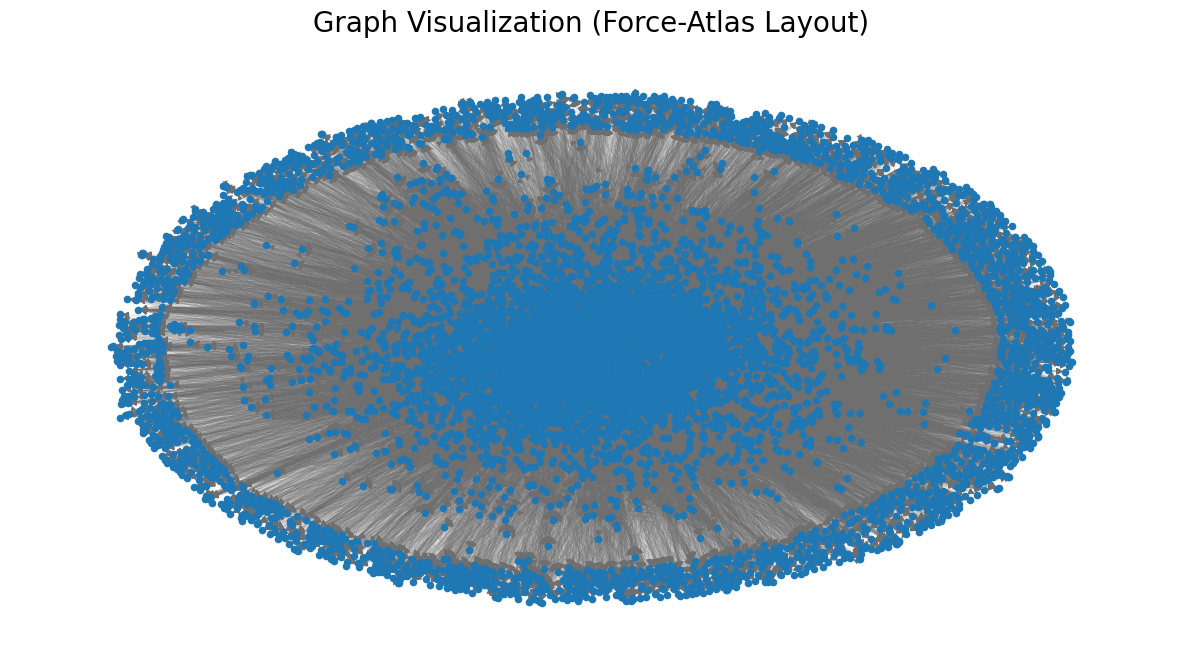

In [3]:
G = graph_creation_top_nodes()
# Calculation of the disposition (layout) - "Force Atlas"
print('Layout calculation')
try:
    pos = nx.forceatlas2_layout(G,gravity=70,max_iter=150,seed=110)
except Exception:
    pos = nx.spring_layout(G, seed=42)

print("Generation of the figure")
plt.figure(figsize=(15, 8))
nx.draw_networkx(
    G,
    pos,
    node_size=20,
    with_labels=False,
    width=0.05,
    edge_color="#706f6f"
)
plt.title(f"Graph Visualization (Force-Atlas Layout)", fontsize=20)

plt.axis('off')

print('Visualization')
plt.show()
plt.close()

In [7]:
def community_detection():
    results = [] 
    G = graph_creation_top_nodes()


    # Louvain community detection
    communities = louvain_communities(G, seed=42)

    for comm in communities:
        # Identify the node with the highest degree as the representative
        representative_article = sorted(comm, key=lambda x: G.in_degree(x), reverse=True)[0]
        results.append({
            'representative_node' : representative_article,
            # Convert set to list for JSON serialization
            'community' : list(comm) 
        })

    with open('data/processed/communities.json', 'w') as outfile:
        # Use indent for better JSON readability
        json.dump(results, outfile, indent=4) 

if __name__ == '__main__':
    community_detection()

Graph found at data/processed/filtered_graph.gpickle. Loading...
Graph loaded successfully: 9932 nodes, 154970 edges.


## Recommandation

In [ ]:
query = ''
